Stock Price Trend Visualization: Fetch historical data (like Apple or Google) and use Matplotlib to plot moving averages. This project helps you practice time-series manipulation and identifying buy/sell signals.

In [1]:
import sys
path_to_lib = r"C:\Users\manuk\AppData\Local\Programs\Python\Python312\Lib\site-packages"
if path_to_lib not in sys.path:
    sys.path.append(path_to_lib)

import yfinance as yf
print(yf.__version__)


1.2.0


In [2]:
import sys
print(sys.executable)
#or use py -3.13 -m pip install yfinance


C:\Users\manuk\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


In [3]:
data = yf.download("AAPL", period="1y")  # Apple, last 1 year
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-03-04  234.906174  239.028223  233.661598  236.678463  53798100
2025-03-05  234.717010  235.523493  228.235251  234.398392  47227600
2025-03-06  234.308777  236.827797  232.148195  233.422640  45170400
2025-03-07  238.032547  240.322554  233.741238  234.089725  46273600
2025-03-10  226.492844  235.135185  223.246996  234.517865  72071200


236.2339393979027


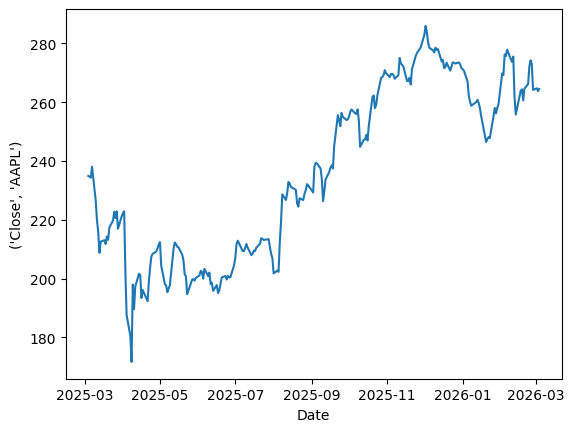

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.DataFrame(data=data)

#the data is a 2 level data, 
#Level 0 (Price Metric): Categorizes the data (Close, Open, etc.).
# Level 1 (Ticker): Specifies the stock symbol (AAPL, TSLA, etc.).

print(df[('Close','AAPL')].mean())
sns.lineplot(df[('Close','AAPL')])
plt.show()

In [5]:
#use of pandas rolling window to calculate the moving average of the closing price
'''In Pandas, a rolling window allows you to perform calculations on a specific "sliding" subset of your data rather than the entire dataset at once.
It is most commonly used in time-series analysis (like stock data) to smooth out short-term fluctuations and identify long-term trends.'''



df['MA20']=df['Close'].rolling(window=20, min_periods=1).mean()
#With min_periods=1: Row 1 will be the average of 1 day, Row 2 the average of 2 days, and so on, until it reaches Row 20 and stays at a 20-day window.
print(df['MA20'])


Date
2025-03-04    234.906174
2025-03-05    234.811592
2025-03-06    234.643987
2025-03-07    235.491127
2025-03-10    233.691470
                 ...    
2026-02-26    268.310262
2026-02-27    268.617334
2026-03-02    268.891463
2026-03-03    268.591083
2026-03-04    268.355678
Name: MA20, Length: 252, dtype: float64


In [6]:
#rolling window for 50 days
df['MA50']=df['Close'].rolling(window=50, min_periods=1).mean()
print(df['MA50'])

Date
2025-03-04    234.906174
2025-03-05    234.811592
2025-03-06    234.643987
2025-03-07    235.491127
2025-03-10    233.691470
                 ...    
2026-02-26    265.393994
2026-02-27    265.200519
2026-03-02    265.007854
2026-03-03    264.851136
2026-03-04    264.702825
Name: MA50, Length: 252, dtype: float64


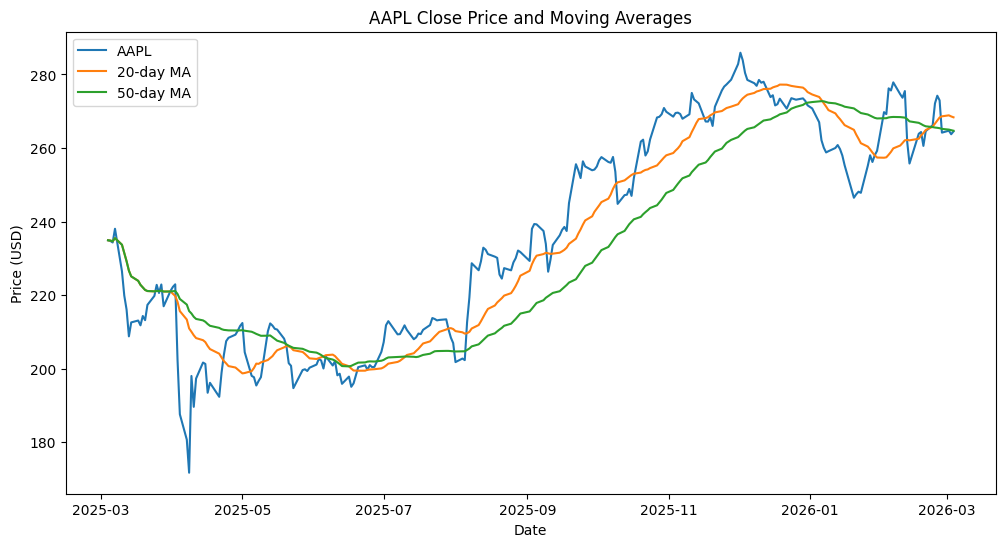

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df['Close'])
sns.lineplot(data=df['MA20'], label='20-day MA')
sns.lineplot(data=df['MA50'], label='50-day MA')
plt.title('AAPL Close Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [8]:
#buy signal

# "Is the short-term trend currently higher than the long-term trend
# Use this if you want to know if it is currently a "Bull Market" or if you want to filter for stocks that are already strong
if df['MA20'].iloc[-1] > df['MA50'].iloc[-1]:
    print("buy")
else:
    print("no buy")

#buy signal when the short-term trend crosses above the long-term trend
# Use this if you want to know when a stock is starting to gain momentum, even if it is not yet strong
if df['MA20'].iloc[-2] < df['MA50'].iloc[-2] and df['MA20'].iloc[-1] > df['MA50'].iloc[-1]:
    print("buy")
else:
    print("no buy")


#If you want to find the exact dates where this happened across your entire historical dataset
df['buy_signals']= (df['MA20']>df['MA50']) & (df['MA20'].shift(1)<=df["MA50"].shift(1))
print(df.columns)
print(df[df['buy_signals']])

buy
no buy
MultiIndex([(      'Close', 'AAPL'),
            (       'High', 'AAPL'),
            (        'Low', 'AAPL'),
            (       'Open', 'AAPL'),
            (     'Volume', 'AAPL'),
            (       'MA20',     ''),
            (       'MA50',     ''),
            ('buy_signals',     '')],
           names=['Price', 'Ticker'])
Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2025-06-05  200.021332  204.128828  199.542777  202.882620  55126100   
2025-07-11  210.519379  211.486437  209.223320  209.931172  39765800   
2026-02-23  266.179993  269.429993  263.380005  263.489990  37308200   

Price             MA20        MA50 buy_signals  
Ticker                                          
Date                                            
2025-06-05  203.304895  203.242378        True  
2025-07-11  203.699126  2

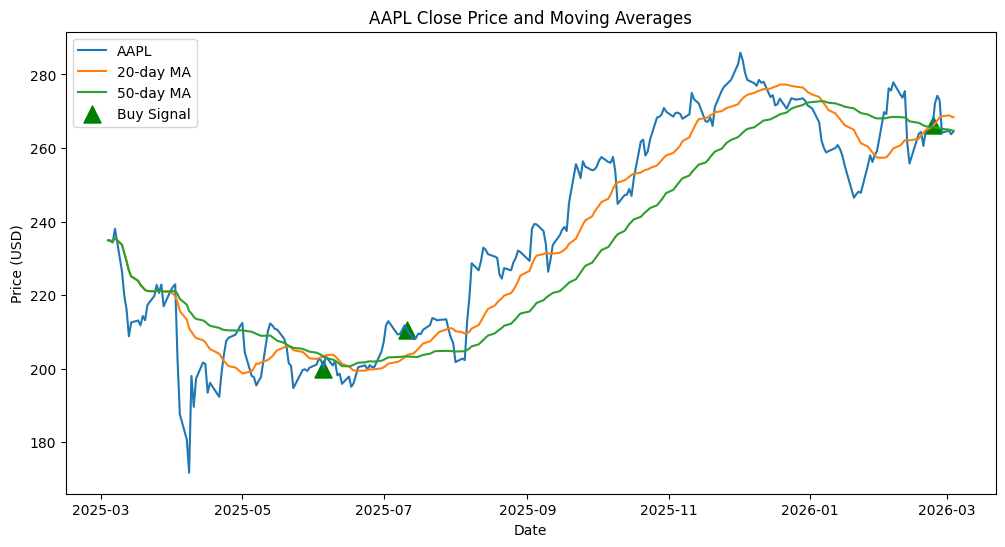

In [9]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df['Close'])
sns.lineplot(data=df['MA20'], label='20-day MA')
sns.lineplot(data=df['MA50'], label='50-day MA')

plt.scatter(
    df[df['buy_signals']].index, 
    df.loc[df['buy_signals'], 'Close'], 
    marker='^', color='g', s=150, label='Buy Signal'
)

plt.title('AAPL Close Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# learning
1. Moving averages-> used to add a rolling window allows you to perform calculations on a specific sliding" subset of your data rather than the entire dataset at once.
It is most commonly used in time-series analysis (like stock data) to smooth out short-term fluctuations and identify long-term trends

2. 	Seaborn (sns): 	Complex statistical plots (Heatmaps, Regressions), Data Format: Likes whole DataFrames (data=df)
   Matplotlib (plt): Precise, custom overlays (Signals on Price), Likes individual arrays/series

   use matplotlib for overlays